# [실습] 공휴일 열 추가 — 주를 나눠 채점하고 누수 고치기

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 공휴일 열을 모든 주에 쓸까

<div style="background:#FFFFFF;color:#000000;padding:40px;border-radius:12px;border:1px solid #E6E6E6;border-left:4px solid #051C2C">
<div style="font-size:0.9em;color:#656565">딥러닝 시계열 · 셋째 날</div>
<h1 style="color:#000000;margin:10px 0">공휴일 열 추가 — 주를 나눠 채점하고 누수 고치기</h1>
<div style="font-size:1.05em;color:#656565">공휴일 열을 Chronos-2 의 미래 입력에 포함해 공휴일 없는 두 주와 공휴일 있는 세 주로 나눠서 다시 채점하고, 미래 입력에 남은 하차 열을 찾아 고칩니다</div>
</div>

**오늘의 질문** 공휴일 열을 입력한 Chronos-2 를 모든 주의 인력 예측에 쓸까요?
자료는 서울 지하철 100개 역의 일별 승하차 기록입니다. 수요일 원점 5개마다 역별로 7일 승차를 예측해 MASE 로 채점하고, 역별 인력은 이 승차 예측으로 정합니다.

공휴일 열을 입력한 Chronos-2 는 평가표에 **「Chronos-2 + 공휴일」** 이라는 이름으로 MASE 를 적습니다. 채점 7일에 평일 공휴일이 없는 원점 2개가 「공휴일 없는 두 주」, 있는 원점 3개가 「공휴일 있는 세 주」입니다. Chronos-2 + 공휴일이 이 두 주와 세 주에서 각각 제로샷보다 MASE 가 낮은지 봅니다.

이어서 같은 파일의 하차 기록처럼 예측 시점에 알 수 없는 값이 미래 입력(`future_df`)에 포함되지 않았는지 확인합니다. 예측 시점은 예측 원점인 수요일의 아침입니다.

1. 맨 위 설치 셀을 한 번 실행합니다. 런타임 유형은 GPU(T4)로 둡니다. 설치 셀이 `DEVICE : cpu` 를 출력하면 메뉴 런타임 → 런타임 유형 변경 → GPU 를 고른 뒤 설치 셀부터 다시 실행합니다.
2. 「오늘의 준비」 셀을 실행해 두고, 출력을 기다리는 동안 개념 확인 두 문항을 풉니다.
3. 노트북을 내려받아 Colab 이나 내 컴퓨터에서 열었다면 맨 위의 접힌 `[채점]` 셀을 한 번 ▶ 실행한 뒤 시작합니다.

In [1]:
# 실습 준비 - 패키지 설치·폰트·GPU 확인·Chronos-2 내려받기
# [heavy]
#  Colab 에서만 chronos-forecasting 2.3.1 · holidays 0.103 을 설치합니다. 내 컴퓨터에서는 이미 깔린 버전을 씁니다.
#  교안의 수를 계산한 버전에 맞춰 고정합니다. 버전을 올리면 분위수와 공휴일 열이 달라질 수 있습니다.
#  numpy · pandas · pyarrow · torch · matplotlib 은 Colab 기본 버전을 그대로 씁니다.
import os, sys, math, time, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "chronos-forecasting==2.3.1", "holidays==0.103"], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트: Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 직접 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil
if IN_COLAB and shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색: 기준선=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다
FIGW = FIG_W      # 도우미가 밑줄을 빼고 FIGW 로 옮겨 적는 일이 있어 같은 값을 하나 더 둔다

try:
    import holidays
    _hol_ver = holidays.__version__
except ImportError:
    _hol_ver = "없음"
print("사용 폰트:", FONT, "| 색 팔레트 준비 완료 | holidays", _hol_ver)

# GPU 확인: 오늘 Chronos-2 예측은 모두 여기서 정한 DEVICE 에서 실행됩니다
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    _gpu = torch.cuda.get_device_properties(0)
    print(f"DEVICE : cuda | GPU {torch.cuda.get_device_name(0)} | 메모리 {_gpu.total_memory / 1e9:.1f} GB"
          f" | torch {torch.__version__}")
else:
    print(f"DEVICE : cpu | GPU 없음 | torch {torch.__version__}")
    print("GPU 가 연결되지 않았습니다. 메뉴 런타임 → 런타임 유형 변경 → GPU 를 고른 뒤 맨 위 셀부터 다시 실행합니다.")
    print("그대로 두면 같은 코드가 CPU 에서 실행되고, Chronos-2 예측이 GPU 보다 10배 넘게 오래 걸립니다.")

# Chronos-2 가중치(약 480MB)를 여기서 한 번 내려받아 둡니다. 준비 셀은 이 사본을 읽습니다.
#  내려받기가 끊기면 10초 쉬고 다시 시도하며, 세 번까지 합니다.
from huggingface_hub import snapshot_download
CHRONOS_ID = "amazon/chronos-2"
for _try in range(1, 4):
    try:
        snapshot_download(CHRONOS_ID, allow_patterns=["config.json", "model.safetensors"])
        print(f"Chronos-2 가중치 준비 완료: {CHRONOS_ID} ({_try}번째 시도)")
        break
    except Exception as _e:
        print(f"Chronos-2 내려받기 {_try}번째 실패: {type(_e).__name__}")
        if _try < 3:
            time.sleep(10)
else:   # 받지 못한 채 넘어가면 뒤 셀의 from_pretrained 가 내려받기 오류로 멈춘다. 여기서 멈춘다
    raise RuntimeError("Chronos-2 가중치를 세 번 모두 받지 못했습니다. LMS 면 이 셀을 다시 실행하고, 그래도 같으면"
                       " 강사에게 알립니다. Colab 이면 메뉴 런타임 → 런타임 다시 시작을 누른 뒤 이 셀부터 다시 실행합니다")

사용 폰트: NanumGothic | 색 팔레트 준비 완료 | holidays 0.103
DEVICE : cuda | GPU Tesla T4 | 메모리 15.6 GB | torch 2.11.0+cu130
Fetching 2 files: 100%|██████████| 2/2 [00:04<00:00,  2.23s/it]
Chronos-2 가중치 준비 완료: amazon/chronos-2 (1번째 시도)


## 서울 지하철 100개 역 준비

자료는 이 과목에서 처음부터 쓴 **서울 지하철 일별 승하차 기록**(서울열린데이터광장 OA-12914)입니다. 기간은 2015년 1월 1일부터 2026년 6월 30일까지입니다.

후보는 이 기간에 기록이 끊기지 않은 역입니다. 그 가운데 서울 지하철 100개 역(2024년까지 하루 평균 승차가 가장 많은 역 100곳)을 골라 표를 만듭니다. 표는 100개 역 × 4,199일입니다. 예측 원점 5개는 지금까지와 같은 수요일입니다.

Chronos-2 는 이번에도 가중치를 고치지 않는 제로샷으로 씁니다. 원점마다 원점 전날까지 512일(컨텍스트)을 입력해 원점부터 7일의 분위수 아홉 개를 받고, 점 예측은 0.5 분위수인 `"0.5"` 열입니다.

「오늘의 준비」 셀은 아래 넷을 출력합니다. GPU 에서 20초 안팎, CPU 에서 1분 안팎 걸립니다.

- 표 1 · 원점 5개의 채점 7일 가운데 공휴일인 날
- 표 2 · 후보 열과 값이 정해지는 때(후보 열은 승차와 함께 입력할지 따져 볼 열)
- 표 3 · 공휴일이 있는 주와 없는 주의 평균 MASE, 계절 나이브와 Chronos-2 제로샷
- 그림 1 · 강남역 설 연휴가 있는 주의 0.5 분위수와 실제, 예측 원점 2026-02-11

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Seoul_subway_linemap_ko.svg" alt="서울 지하철 노선도, 호선마다 색이 다른 선 위에 역 이름이 이어진 그림" width="560" height="637"/>
<p align="center"><em>▲ 서울 지하철 노선도. 표 2 의 호선은 역마다 이 그림에서 하나로 정해지고 날마다 바뀌지 않는다 (출처: Wikimedia Commons, Seoul subway linemap ko.svg)</em></p>

표 1 · 원점 5개의 채점 7일 가운데 공휴일인 날
  2025-08-13 · 공휴일 있는 주 · 08-15(금)
  2025-10-01 · 공휴일 있는 주 · 10-03(금) 10-05(일, 주말 공휴일) 10-06(월) 10-07(화)
  2025-12-10 · 공휴일 없는 주 · 없음
  2026-02-11 · 공휴일 있는 주 · 02-16(월) 02-17(화)
  2026-06-24 · 공휴일 없는 주 · 없음

표 2 · 후보 열과 값이 정해지는 때
  목표일 요일 · 달력으로 미리 정해진다
  공휴일 · 달력으로 미리 정해진다 (임시공휴일은 지정된 뒤부터)
  호선 · 역마다 하나로 정해져 날마다 같다
  목표일 하차 인원 · 그날이 지나야 기록된다
  실측 기온 · 그날이 지나야 기록된다
  기온 예보 · 예측 시점까지 발표된다
Loading weights: 100%|██████████| 170/170 [00:00<00:00, 1028.07it/s]

표 3 · 공휴일이 있는 주와 없는 주의 평균 MASE, 계절 나이브와 Chronos-2 제로샷
  계절 나이브 : 공휴일 없는 두 주 0.445 · 공휴일 있는 세 주 2.767 · 원점 5개 평균 1.838
  Chronos-2 제로샷 : 공휴일 없는 두 주 0.271 · 공휴일 있는 세 주 2.763 · 원점 5개 평균 1.766


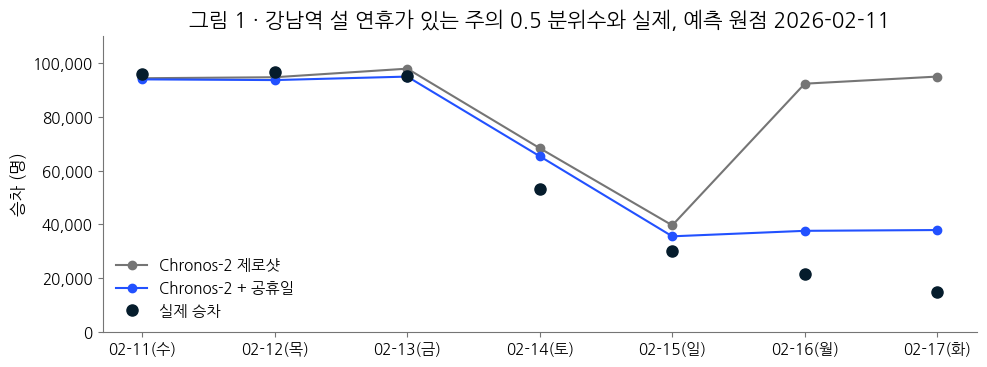

In [2]:
# 오늘의 준비 — 읽고 실행만 합니다
# 서울 지하철 100개 역으로 표 1 · 표 2 · 표 3 · 그림 1 을 만듭니다. GPU 에서 20초 안팎, CPU 에서 1분 안팎 걸립니다
# Chronos-2 를 불러오다 내려받기 오류(Hugging Face)가 나면 맨 위 설치 셀부터 다시 실행합니다
RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 지금까지와 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False, observed=True)[["board"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]
MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]
assert MAT.shape == (100, 4199) and STATIONS[0] == "2호선 강남"

H, CTX = 7, 512                               # 예측 7일 · Chronos-2 에 주는 과거 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]


def origin_ctx(origin):
    """원점 하나의 자료: 원점 열 번호(o), 원점 전날까지(hist), 채점 7일(test, 명), 역별 MASE 분모(qden)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden, test_dates=DATES[o:o + H])


def hol_flags(dates):
    """날짜마다 한국 공휴일이면 1, 아니면 0 (holidays 0.103 KR, 주말 공휴일 포함)"""
    import holidays
    di = pd.DatetimeIndex(dates)
    kr = holidays.KR(years=sorted(set(di.year)))
    return np.array([1.0 if d in kr else 0.0 for d in di], dtype=np.float32)


HOL = hol_flags(DATES)

# 표 1: 원점마다 채점 7일 가운데 공휴일 열 값이 1 인 날(주말 공휴일 포함)
WEEKDAY = "월화수목금토일"
HOLIDAY_DATES = {}
print("표 1 · 원점 5개의 채점 7일 가운데 공휴일인 날")
for o in ORIGINS:
    c = origin_ctx(o)
    days = [d for d, h in zip(c["test_dates"], HOL[c["o"]:c["o"] + H]) if h == 1]
    HOLIDAY_DATES[o] = [f"{d:%m-%d}({WEEKDAY[d.weekday()]}" + (", 주말 공휴일)" if d.weekday() >= 5 else ")")
                        for d in days]
    group = "공휴일 없는 주" if o in PLAIN_ORIGINS else "공휴일 있는 주"
    print(f"  {o} · {group} · {' '.join(HOLIDAY_DATES[o]) or '없음'}")

# 표 2: 후보 열마다 값이 정해지는 때
CAND = pd.DataFrame({"col": ["목표일 요일", "공휴일", "호선", "목표일 하차 인원", "실측 기온", "기온 예보"],
                     "when": ["달력으로 미리 정해진다", "달력으로 미리 정해진다", "역마다 하나로 정해져 날마다 같다",
                              "그날이 지나야 기록된다", "그날이 지나야 기록된다", "예측 시점까지 발표된다"]})
print("\n표 2 · 후보 열과 값이 정해지는 때")
for col, when in zip(CAND["col"], CAND["when"]):
    print(f"  {col} · {when}" + (" (임시공휴일은 지정된 뒤부터)" if col == "공휴일" else ""))

# Chronos-2 를 DEVICE 에 올립니다. 끊기면 세 번까지 다시 시도합니다
from chronos import BaseChronosPipeline
PIPE = None
for _try in range(1, 4):
    try:
        PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
        break
    except Exception as _e:
        print(f"Chronos-2 불러오기 {_try}번째 실패: {type(_e).__name__}")
        time.sleep(5)


def chronos_frames(origin, holiday=True):
    """predict_df 에 넘길 (df, future_df). df 는 원점 전날까지 512일, future_df 는 채점 7일의 공휴일"""
    c = origin_ctx(origin)
    o, S = c["o"], MAT.shape[0]
    df = pd.DataFrame({"item_id": np.repeat(np.arange(S), CTX),
                       "timestamp": np.tile(DATES[o - CTX:o].values, S),
                       "target": MAT[:, o - CTX:o].ravel()})
    future_df = None
    if holiday:
        df["holiday"] = np.tile(HOL[o - CTX:o].astype(float), S)
        future_df = pd.DataFrame({"item_id": np.repeat(np.arange(S), H),
                                  "timestamp": np.tile(c["test_dates"].values, S),
                                  "holiday": np.tile(HOL[o:o + H].astype(float), S)})
    return df, future_df


def to_q(fc):
    """predict_df 결과 표를 역 순서대로 정렬해 100 x 7 x 9 분위수 배열로 모읍니다"""
    fc = fc.sort_values(["item_id", "timestamp"])
    return np.stack([fc[str(t)].to_numpy().reshape(-1, H) for t in QS], axis=-1)


# 표 3: 원점마다 역별 MASE 의 100개 역 평균, 계절 나이브(7일 전 같은 요일)와 Chronos-2 제로샷
Q_ZS, _mase, _cache = {}, {"계절 나이브": {}, "Chronos-2 제로샷": {}}, []
for o in ORIGINS:
    c = origin_ctx(o)
    fc = PIPE.predict_df(chronos_frames(o, holiday=False)[0], prediction_length=H, quantile_levels=QS)
    Q_ZS[o] = to_q(fc)
    _cache.append(fc.sort_values(["item_id", "timestamp"]).assign(origin=o))
    for name, point in [("계절 나이브", MAT[:, c["o"] - 7:c["o"]]), ("Chronos-2 제로샷", Q_ZS[o][..., 4])]:
        _mase[name][o] = float(np.mean(np.abs(c["test"] - point) / c["qden"][:, None]))
pd.concat(_cache)[["origin", "item_id", "timestamp"] + [str(t) for t in QS]].to_parquet("c2_zs_q.parquet")
GROUP_MASE = {name: (float(np.mean([m[o] for o in PLAIN_ORIGINS])), float(np.mean([m[o] for o in HOL_ORIGINS])),
                     float(np.mean([m[o] for o in ORIGINS]))) for name, m in _mase.items()}
print("\n표 3 · 공휴일이 있는 주와 없는 주의 평균 MASE, 계절 나이브와 Chronos-2 제로샷")
for name, (p, h, m) in GROUP_MASE.items():
    print(f"  {name} : 공휴일 없는 두 주 {p:.3f} · 공휴일 있는 세 주 {h:.3f} · 원점 5개 평균 {m:.3f}")

# 그림 1: 강남역 한 역만 공휴일 열을 입력해 예측하고, 제로샷·실제와 나란히 그립니다
c, _o = origin_ctx("2026-02-11"), "2026-02-11"
_df, _fdf = chronos_frames(_o, holiday=True)
SEOL_Y, SEOL_ZS = c["test"][0], Q_ZS[_o][0, :, 4]
SEOL_HOL = to_q(PIPE.predict_df(_df[_df.item_id == 0], future_df=_fdf[_fdf.item_id == 0],
                                prediction_length=H, quantile_levels=QS))[0, :, 4]
days = [f"{d:%m-%d}({WEEKDAY[d.weekday()]})" for d in c["test_dates"]]
fig, ax = plt.subplots(figsize=(FIG_W, 3.8))
ax.plot(days, SEOL_ZS, color=COL["회색"], marker="o", label="Chronos-2 제로샷")
ax.plot(days, SEOL_HOL, color=COL["파랑"], marker="o", label="Chronos-2 + 공휴일")
ax.plot(days, SEOL_Y, "o", color=COL["남색"], markersize=8, label="실제 승차")
ax.set_title("그림 1 · 강남역 설 연휴가 있는 주의 0.5 분위수와 실제, 예측 원점 2026-02-11")
ax.set_ylabel("승차 (명)")
ax.set_ylim(0, 110000)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.legend(loc="lower left", frameon=False)
plt.show()

## 공변량 확인

> **[문제] Chronos-2 의 df 에만 남긴 하차 열은 어떻게 쓰이나요?**
>
> 예를 들어 df 에 역·날짜·승차·공휴일·하차 다섯 열을, future_df 에 역·날짜·공휴일 세 열을 넘긴다고 합시다.
>
> 1. 원점 전날까지 512일의 하차만 과거 공변량으로 쓰인다
> 2. 채점 7일의 하차까지 읽혀 누수가 된다
> 3. future_df 에 없는 열이라 오류가 난다

> **[문제] 공변량을 추가해 평균이 좋아진 모델을 모든 주에 쓸까요?**
>
> 예를 들어 공변량을 추가하기 전 → 추가한 뒤 MASE 가 원점 5개 평균 1.8 → 0.8, 공휴일 없는 두 주 0.30 → 0.35, 공휴일 있는 세 주 2.8 → 1.1 로 바뀌었다고 합시다.
>
> 1. 평균이 절반 아래로 줄었으니 모든 주에 공변량을 넣은 모델을 쓴다
> 2. 평일 공휴일이 있는 주는 공변량을 넣은 모델을 쓰고, 공휴일 없는 주는 평균 하나로 정하지 않고 따로 따진다
> 3. 공휴일 없는 두 주가 나빠졌으니 공변량을 모든 주에서 뺀다

## 서울 지하철 100개 역으로 판단하기

아래 세 문항은 「오늘의 준비」 셀 출력을 읽고 답합니다. 표 3 은 공휴일 열 없이 예측한 두 모델(계절 나이브 · Chronos-2 제로샷)의 MASE 를 공휴일 유무로 나눈 값입니다. 그림 1 은 강남역 한 역에만 공휴일 열을 입력해 예측한 결과입니다. 표 2 는 후보 열마다 값이 언제 정해지는지를 정리한 표입니다.

> **[문제] 설 두 날의 Chronos-2 + 공휴일 예측**
>
> 「오늘의 준비」 셀을 실행하면 나오는 「그림 1 · 강남역 설 연휴가 있는 주의 0.5 분위수와 실제, 예측 원점 2026-02-11」을 봅니다. 공휴일 열을 입력한 뒤 2월 16일·17일 예측은 어디까지 내려왔나요?
>
> 1. 두 날 모두 실제 승차 가까이까지 내려왔다
> 2. 제로샷과 거의 같은 높이에 머물렀다
> 3. 크게 내려왔지만 두 날 모두 실제보다 높다

> **[문제] 공휴일 없는 두 주에서 Chronos-2 + 공휴일과 비교할 모델**
>
> 「오늘의 준비」 셀을 실행하면 나오는 「표 3 · 공휴일이 있는 주와 없는 주의 평균 MASE, 계절 나이브와 Chronos-2 제로샷」을 봅니다. Chronos-2 + 공휴일을 공휴일 없는 주에도 쓸지 정하려면, 공휴일 없는 두 주에서 그 모델의 MASE 를 어느 모델과 비교해야 할까요?
>
> 1. 제로샷과 계절 나이브 둘 다: 두 모델과의 MASE 차를 각각 0.077 과 비교한다
> 2. 계절 나이브만: Chronos-2 + 공휴일도 계절 나이브보다 낮으면 공휴일 없는 주에 쓴다
> 3. 원점 5개 평균만: 평균이 낮아지면 공휴일이 있는 주와 없는 주 모두 낮아진 것이다

> **[문제] future_df 에 넣을 열**
>
> 「오늘의 준비」 셀을 실행하면 나오는 「표 2 · 후보 열과 값이 정해지는 때」를 봅니다. future_df 에 포함해도 누수가 아닌 열만 모은 것은 무엇인가요?
>
> 1. 공휴일, 목표일 하차 인원
> 2. 목표일 요일, 공휴일
> 3. 목표일 요일, 실측 기온

## 미션 1 — Chronos-2 + 공휴일을 공휴일 유무로 나눠 채점

공휴일 없는 두 주는 제로샷과 계절 나이브 둘 다와 비교합니다. 데이터 퀴즈 「공휴일 없는 두 주에서 Chronos-2 + 공휴일과 비교할 모델」에서 정한 기준입니다. 공휴일 있는 세 주는 제로샷이 계절 나이브와 같았던 값(2.763 대 2.767)에서 얼마나 내려오는지 봅니다. 두 모델의 평균 MASE 차이는 MLP(MSE 손실)의 시드 범위 0.077 과 비교하고, 더 작으면 차이가 있다고 보지 않습니다.

#### 할 일 — 미션 1 (25분)

1. 아래 「미션 1 준비 셀」을 실행합니다. 이 셀은 고치지 않습니다.
2. 아래 「만들 것」대로 시킬 일을 「PROMPT 셀」의 `PROMPT = """ """` 따옴표 안에 내 말로 적습니다. 예시 프롬프트도 따옴표 안에 붙여 넣어야 채점됩니다.
3. 셀을 선택한 채로 AI 튜터에게 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶ 합니다. LMS 밖이면 받은 코드를 AI 코드 표시선(`# --- 여기부터 AI 코드 ---`) 아래에 둡니다.
4. 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 3번부터 다시 합니다.

**이 미션의 질문**: Chronos-2 + 공휴일은 공휴일 없는 두 주와 공휴일 있는 세 주에서 각각 제로샷보다 MASE 가 낮을까요?

**쓸 수 있는 것**: 「미션 1 준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 |
|---|---|
| `ORIGINS` · `PLAIN_ORIGINS` · `HOL_ORIGINS` · `QS` · `H` | 원점 5개 · 공휴일 없는 두 주 · 공휴일 있는 세 주 · 분위수 아홉 개(0.1～0.9) · 예측 7일 |
| `PIPE` | DEVICE 에 올린 Chronos-2. `PIPE.predict_df(df, future_df=future_df, prediction_length=H, quantile_levels=QS)` 의 결과 표는 `item_id`·`timestamp` 한 행마다 `"0.1"`～`"0.9"` 열을 담는다 |
| `chronos_frames(origin, holiday=True)` | `predict_df` 에 넘길 두 표 `(df, future_df)`. `item_id` 는 `MAT` 의 행 번호 0～99. `holiday=False` 면 제로샷용이라 `future_df` 가 `None` 이다 |
| `origin_ctx(origin)` · `score(y, pred, qden)` · `Q_ZS` | `origin_ctx(o)["test"]` 는 채점 7일 실제 승차(100 × 7, 명), `["qden"]` 은 역별 MASE 분모 100개. `score` 는 MASE·RMSE 를 dict 로 반환한다. `Q_ZS[o]` 는 제로샷 분위수(100 × 7 × 9) |
| `COL` · `FIG_W` | 그래프 색 사전과 그림 가로 크기(설치 셀) |

#### 만들 것

굵은 이름은 채점이 찾으니 글자 그대로 쓰고, 셋 모두 「PROMPT 셀」에서 출력합니다.

1. **공휴일 있는 세 주 MASE(Chronos-2 + 공휴일)**: 소수 셋째 자리. 원점마다 역별 MASE(`"0.5"` 열)의 100개 역 평균을 구한 뒤 `HOL_ORIGINS` 세 원점을 평균한 값
2. **공휴일 없는 두 주 MASE(Chronos-2 + 공휴일)**: 같은 방식으로 `PLAIN_ORIGINS` 두 원점을 평균한 값
3. **그래프 한 장**: 종류는 자유이고 가로축 「예측 원점」, 세로축 「MASE」 이름을 답니다. 권장은 원점 5개마다 두 모델(Chronos-2 제로샷 · Chronos-2 + 공휴일)을 나란히 둔 막대입니다

함께 볼 것(채점 밖): 원점별 두 모델 MASE 표와, 제로샷보다 MASE 가 낮아진 건수와 높아진 건수.

**통과 기준**: 1·2번 값이 「이름 = 값」 한 행씩 있고 기준 범위 안이며, 그래프에 가로축·세로축 이름이 있으면 통과입니다.

#### 프롬프트에 넣을 것(힌트)

- **고정할 이름**: 위 표의 이름은 다시 만들지 말라고 적습니다.
- **공휴일 열**: `chronos_frames` 를 `holiday=True` 로 불러 두 표를 모두 `predict_df` 에 넘기라고 적습니다.
- **모으는 순서**: 결과 표를 `item_id`·`timestamp` 순으로 정렬해 `"0.5"` 열을 100 × 7 로 모으라고 적습니다.
- **평균하는 순서**: 원점 5개를 모두 예측해 원점별 값을 먼저 구한 뒤 공휴일 없는 두 주와 공휴일 있는 세 주를 따로 평균하라고 적습니다.

<details class="lms-extra"><summary>자세히 — 예시 프롬프트</summary>

위 표의 이름은 새로 만들지 말고, ORIGINS 원점마다 chronos_frames(원점, holiday=True) 의 df 와 future_df 를 PIPE.predict_df 에 넘겨 예측한 뒤 결과 표를 item_id, timestamp 순으로 정렬해 "0.5" 열을 100 x 7 로 모아 줘. origin_ctx 의 test 와 qden 을 score 에 전달해 원점별 MASE 를 구하고, 공휴일 있는 세 주 평균은 "공휴일 있는 세 주 MASE(Chronos-2 + 공휴일) = 값" 한 행으로 출력해 줘. 공휴일 없는 두 주 평균은 "공휴일 없는 두 주 MASE(Chronos-2 + 공휴일) = 값" 한 행으로 출력하고, Q_ZS 의 0.5 분위수로 같게 구한 제로샷 MASE 와 나란히 원점별 표도 찍어 줘. 원점 5개마다 두 모델 막대를 나란히 놓고 가로축 "예측 원점", 세로축 "MASE", 범례를 달아 줘.

</details>

#### 예상 적기

> **[예측] 공휴일 없는 두 주는 채점 7일의 공휴일 열이 모두 0 입니다. 공휴일 열을 입력하면 이 두 주의 평균 MASE 는 제로샷 0.271 과 비교해 어떻게 나올까요?**
>
> 1. 0.077 보다 큰 차이로 낮아진다
> 2. 차이가 0.077 보다 작다
> 3. 0.077 보다 큰 차이로 높아진다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

<details class="lms-extra"><summary>더 깊이 — Chronos-2 가 공휴일 열을 받는 두 곳</summary>

공휴일 열은 두 곳으로 들어갑니다. `df` 의 과거 512일과 `future_df` 의 채점 7일입니다. Chronos-2 는 한 역의 승차 계열과 그 역의 공휴일 계열을 한 **그룹(group)** 으로 받고, 두 계열을 16일씩 묶은 패치로 나눕니다. 그룹 어텐션은 같은 16일의 공휴일 패치 값을 승차 패치에 가중 평균으로 섞습니다. 채점 7일은 승차 값이 비어 있고 공휴일 값만 있는 패치 하나로 들어갑니다. `chronos_frames` 는 기본 설정을 그대로 두어 다른 역의 계열은 한 그룹으로 묶지 않습니다.

<img src="https://arxiv.org/html/2510.15821v1/x1.png" alt="Chronos-2 구조, 입력의 목표 계열과 Known Covariate, 토큰화, 시간 어텐션과 그룹 어텐션, 분위수 출력층" width="640" height="264"/>
<p align="center"><em>▲ Chronos-2 의 구조. 왼쪽 INPUT 의 Known Covariate 점선이 FUTURE 쪽까지 이어지는 것이 미래 공변량이다. 미션 1 에서는 공휴일 열이 이 위치에 들어가고, 강남역 승차와 강남역 공휴일이 한 그룹이다 (출처: Ansari 외, Chronos-2: From Univariate to Universal Forecasting, arXiv:2510.15821 Figure 1)</em></p>

</details>

<details class="lms-extra"><summary>자세히 — AI 튜터에 맡길 일과 내가 확인할 일</summary>

오른쪽은 **틀려도 오류가 나지 않아** 내가 확인해야 하는 일입니다.

| AI 튜터에 맡길 일 | 내가 확인할 일 |
|---|---|
| 원점 5개를 도는 반복과 `PIPE.predict_df` 호출 | `chronos_frames` 를 `holiday=True` 로 불렀는가, `future_df` 를 넘겼는가. 넘기지 않아도 오류는 나지 않는다 |
| 결과 표를 100 × 7 × 9 배열로 모으기 | `item_id`·`timestamp` 순으로 정렬했는가. 역 순서가 `MAT` 와 어긋나도 오류는 나지 않는다 |
| 두 주 · 세 주의 평균과 그래프 | 반복문이 원점 5개를 모두 돌았는가, 두 평균이 원점별 값의 평균인가, 원점 5개를 공휴일 없는 두 주와 공휴일 있는 세 주로 바르게 나눴는가 |

</details>

<details class="lms-extra"><summary>예상 확인 — 미션 1 결과를 본 뒤 펼칩니다</summary>

답은 둘째 보기입니다. 공휴일 없는 두 주는 제로샷 0.271 에서 Chronos-2 + 공휴일 0.322 로 0.051 높아졌지만, 시드 범위 0.077 보다 작아 차이가 있다고 보지 않습니다. 원점 2025-12-10(공휴일 없는 주)은 0.279 에서 0.309 로 바뀌었습니다. 원점 2026-06-24(공휴일 없는 주)는 0.263 에서 0.335 로 바뀌었습니다.

- 공휴일 없는 두 주의 차이 0.051 은 0.077 보다 작아, 평균 MASE 만으로는 어느 모델이 더 낫다고 하지 않습니다
- 역 100개와 원점 2개의 조합 200건 가운데 148건은 MASE 가 높아졌고, 제로샷보다 낮아진 것은 52건(26%)입니다
- 공휴일 없는 주에 무엇을 쓸지는 이론 팀 라운드에서 정한 입장을 따릅니다

보기마다 까닭은 이렇습니다.

- 「0.077 보다 큰 차이로 낮아진다」: 채점 7일의 공휴일 열이 모두 0 이라 미래 입력으로 더해진 정보가 없습니다. 크게 낮아진 것은 공휴일 있는 세 주(2.763 에서 1.022)입니다.
- 「0.077 보다 큰 차이로 높아진다」: 과거 512일의 입력에 공휴일 열이 더해져 역마다 예측이 바뀌었고, 200건 가운데 148건에서 MASE 가 높아졌습니다. 그러나 0.077 은 평균 MASE 끼리 비교하는 기준이라 건수에는 쓰지 않습니다. 평균의 차이 0.051 은 0.077 보다 작아 차이가 있다고 보지 않습니다.

</details>

In [3]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 이름을 직접 만듭니다
#  자료를 다시 불러오고 Chronos-2 를 DEVICE 에 올립니다. 제로샷 분위수는 「오늘의 준비」 셀이 남긴
#  c2_zs_q.parquet 를 읽고, 그 파일이 없으면 여기서 다시 예측합니다(GPU 몇 초, CPU 30초 안팎)
RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 지금까지와 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False, observed=True)[["board"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]
MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]

H, CTX = 7, 512                               # 예측 7일 · Chronos-2 에 주는 과거 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]                 # 공휴일 없는 두 주: 채점 7일에 평일 공휴일이 없다
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]     # 공휴일 있는 세 주: 채점 7일에 평일 공휴일이 있다


def origin_ctx(origin):
    """원점 하나의 자료: 원점 열 번호(o), 원점 전날까지(hist), 채점 7일(test, 명), 역별 MASE 분모(qden)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)   # 원점 전날까지로 계산한 분모
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden, test_dates=DATES[o:o + H])


def hol_flags(dates):
    """날짜마다 한국 공휴일이면 1, 아니면 0 (holidays 0.103 KR, 주말 공휴일 포함)"""
    import holidays
    di = pd.DatetimeIndex(dates)
    kr = holidays.KR(years=sorted(set(di.year)))
    return np.array([1.0 if d in kr else 0.0 for d in di], dtype=np.float32)


HOL = hol_flags(DATES)


def score(y, pred, qden):
    """MASE(역별 MASE 의 100개 역 평균)와 RMSE(명)를 dict 로 돌려줍니다. y·pred 는 100 x 7"""
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    return dict(mase=float(np.mean(np.abs(y - pred) / np.asarray(qden)[:, None])),
                rmse=float(np.sqrt(np.mean((y - pred) ** 2))))


# Chronos-2 를 DEVICE 에 올립니다. 끊기면 세 번까지 다시 시도합니다
from chronos import BaseChronosPipeline
PIPE = None
for _try in range(1, 4):
    try:
        PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
        break
    except Exception as _e:
        print(f"Chronos-2 불러오기 {_try}번째 실패: {type(_e).__name__}")
        time.sleep(5)


def chronos_frames(origin, holiday=True):
    """predict_df 에 넘길 두 표 (df, future_df) 를 만듭니다

    df        : 100개 역 x 원점 전날까지 512일. item_id(MAT 의 행 번호 0~99) · timestamp · target(승차, 명)
                · holiday(공휴일 1/0). holiday=False 면 holiday 열이 없습니다
    future_df : 100개 역 x 채점 7일. item_id · timestamp · holiday(달력이 정한 공휴일). holiday=False 면 None
    채점 7일의 승차는 어느 표에도 없습니다
    """
    c = origin_ctx(origin)
    o, S = c["o"], MAT.shape[0]
    df = pd.DataFrame({"item_id": np.repeat(np.arange(S), CTX),
                       "timestamp": np.tile(DATES[o - CTX:o].values, S),
                       "target": MAT[:, o - CTX:o].ravel()})
    future_df = None
    if holiday:
        df["holiday"] = np.tile(HOL[o - CTX:o].astype(float), S)
        future_df = pd.DataFrame({"item_id": np.repeat(np.arange(S), H),
                                  "timestamp": np.tile(c["test_dates"].values, S),
                                  "holiday": np.tile(HOL[o:o + H].astype(float), S)})
    assert df["timestamp"].max() < pd.Timestamp(origin)   # 과거 표에는 원점 전날까지만
    return df, future_df


# 제로샷 분위수 Q_ZS: 원점 → 100 x 7 x 9. 파일이 있으면 읽고, 없으면 다시 예측합니다
Q_ZS = {}
if os.path.exists("c2_zs_q.parquet"):
    _z = pd.read_parquet("c2_zs_q.parquet")
    for o in ORIGINS:
        _d = _z[_z["origin"] == o].sort_values(["item_id", "timestamp"])
        Q_ZS[o] = np.stack([_d[str(t)].to_numpy().reshape(-1, H) for t in QS], axis=-1)
else:
    for o in ORIGINS:
        _fc = PIPE.predict_df(chronos_frames(o, holiday=False)[0], prediction_length=H, quantile_levels=QS)
        _fc = _fc.sort_values(["item_id", "timestamp"])
        Q_ZS[o] = np.stack([_fc[str(t)].to_numpy().reshape(-1, H) for t in QS], axis=-1)
assert all(Q_ZS[o].shape == (100, H, len(QS)) for o in ORIGINS)

_df, _fdf = chronos_frames("2026-02-11")
print(f"행렬 : 승차 MAT {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일 · {DATES[0].date()} ~ {DATES[-1].date()}")
print(f"원점 5개 : 공휴일 없는 두 주 {' · '.join(PLAIN_ORIGINS)} / 공휴일 있는 세 주 {' · '.join(HOL_ORIGINS)}")
print(f"chronos_frames(원점) : df 열 {list(_df.columns)} {len(_df):,}행 · future_df 열 {list(_fdf.columns)} {len(_fdf)}행")
print(f"Q_ZS : 원점마다 역 x 7일 x 분위수 9개 {Q_ZS[ORIGINS[0]].shape} · Chronos-2 DEVICE {DEVICE}")
print("쓸 수 있는 이름 : ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS · H · CTX · PIPE"
      " · chronos_frames(origin, holiday=True) · origin_ctx(origin) · score(y, pred, qden) · Q_ZS"
      " · MAT · DATES · STATIONS · HOL")

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 885.63it/s]
행렬 : 승차 MAT 100개 역 x 4,199일 · 2015-01-01 ~ 2026-06-30
원점 5개 : 공휴일 없는 두 주 2025-12-10 · 2026-06-24 / 공휴일 있는 세 주 2025-08-13 · 2025-10-01 · 2026-02-11
chronos_frames(원점) : df 열 ['item_id', 'timestamp', 'target', 'holiday'] 51,200행 · future_df 열 ['item_id', 'timestamp', 'holiday'] 700행
Q_ZS : 원점마다 역 x 7일 x 분위수 9개 (100, 7, 9) · Chronos-2 DEVICE cuda
쓸 수 있는 이름 : ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS · H · CTX · PIPE · chronos_frames(origin, holiday=True) · origin_ctx(origin) · score(y, pred, qden) · Q_ZS · MAT · DATES · STATIONS · HOL


공휴일 있는 세 주 MASE(Chronos-2 + 공휴일) = 1.022
공휴일 없는 두 주 MASE(Chronos-2 + 공휴일) = 0.322

         원점         묶음  제로샷 MASE  Chronos-2 + 공휴일 MASE   차이  낮아진 역 수  높아진 역 수
0  2025-08-13  공휴일 있음        1.115                    0.621 -0.494            92             8
1  2025-10-01  공휴일 있음        4.238                    1.303 -2.935           100             0
2  2025-12-10  공휴일 없음        0.279                    0.309  0.030            37            63
3  2026-02-11  공휴일 있음        2.935                    1.141 -1.794           100             0
4  2026-06-24  공휴일 없음        0.263                    0.335  0.072            15            85

공휴일 있는 세 주 제로샷 평균 MASE = 2.763
공휴일 없는 두 주 제로샷 평균 MASE = 0.271

공휴일 있는 세 주 — 낮아진 역 수 합계 = 292, 높아진 역 수 합계 = 8
공휴일 없는 두 주 — 낮아진 역 수 합계 = 52, 높아진 역 수 합계 = 148

공휴일 있는 세 주: 두 모델 평균 MASE 차이 1.741 vs 시드 범위 0.077 → 차이가 있다고 본다
공휴일 없는 두 주: 두 모델 평균 MASE 차이 -0.051 vs 시드 범위 0.077 → 차이가 있다고 보지 않는다

──────────────────────────────────────────────────────
◼ 미션 1 채점 결과
✅ 공휴일 있는

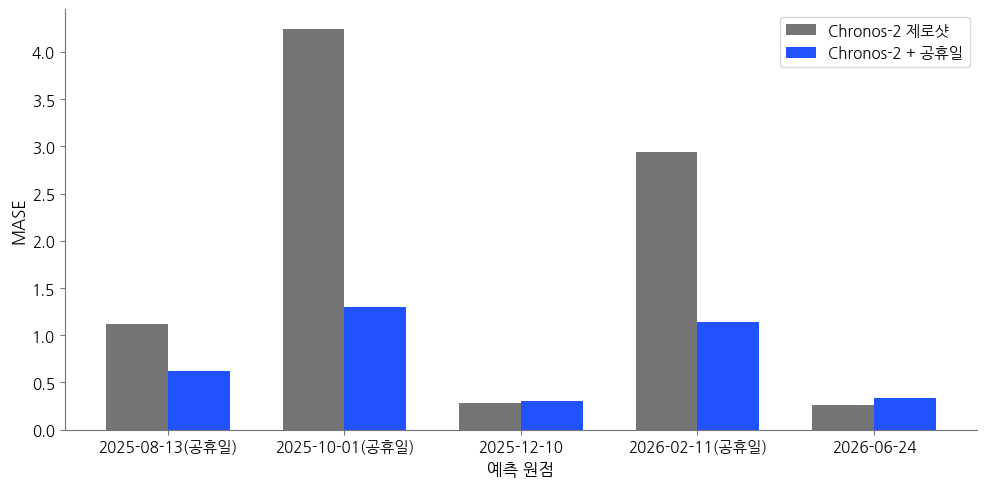

In [5]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → AI 튜터에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
# 시킬 일은 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 예시 프롬프트도 따옴표 안에 붙여 넣어야 채점됩니다
PROMPT = """
미션 1 준비 셀이 만든 이름(ORIGINS, PLAIN_ORIGINS, HOL_ORIGINS, QS, H, PIPE, chronos_frames, origin_ctx, score, Q_ZS, COL, FIG_W)은 다시 만들거나 덮어쓰지 말고 그대로 써.

1. 원점 5개(ORIGINS)를 모두 예측해.
   - 원점마다 df, future_df = chronos_frames(origin, holiday=True) 로 공휴일 열이 든 두 표를 받아.
   - PIPE.predict_df(df, future_df=future_df, prediction_length=H, quantile_levels=QS) 로 두 표를 모두 넘겨 예측해. future_df 를 빼먹지 마.
   - 결과 표를 item_id, timestamp 순으로 정렬하고 "0.5" 열을 (100개 역 × 7일) 배열 pred_hol 로 모아. 행 순서가 item_id 0~99 가 되게 해.
   - 제로샷 예측은 새로 만들지 말고 Q_ZS[origin] (100 × 7 × 9) 에서 QS 의 0.5 위치(인덱스 4) 를 꺼내 pred_zs 로 써.
   - c = origin_ctx(origin) 의 c["test"] 와 c["qden"] 으로 score(...)["mase"] 를 두 모델 각각 구해 원점별 MASE 로 저장해.
   - 역별 MASE 도 구해: 역마다 7일 평균 절대 오차를 qden 으로 나눈 100개 값. 두 모델을 역끼리 비교해서 Chronos-2 + 공휴일이 제로샷보다 낮아진 역 수와 높아진 역 수를 원점마다 세.

2. 원점별 값을 먼저 다 구한 뒤에 묶음 평균을 내. HOL_ORIGINS 세 원점과 PLAIN_ORIGINS 두 원점을 따로 평균해.

3. 출력: 아래 두 줄을 이 이름 그대로, 소수 셋째 자리로 출력해.
   - 공휴일 있는 세 주 MASE(Chronos-2 + 공휴일) = 값
   - 공휴일 없는 두 주 MASE(Chronos-2 + 공휴일) = 값
   그 밑에 참고로 원점별 표(원점, 묶음, 제로샷 MASE, Chronos-2 + 공휴일 MASE, 차이, 낮아진 역 수, 높아진 역 수)와 두 묶음의 제로샷 평균 MASE, 묶음별 낮아진 건수/높아진 건수 합계도 출력해. 두 묶음 각각 두 모델 평균 차이를 시드 범위 0.077 과 비교한 문장도 한 줄씩 적어.

4. 그래프 한 장: 원점 5개마다 Chronos-2 제로샷과 Chronos-2 + 공휴일 막대를 나란히 그린 막대그래프. 가로축 이름은 「예측 원점」, 세로축 이름은 「MASE」로 달고, 범례에 두 모델을 표시하고, 공휴일 있는 원점은 x축 눈금 이름에 (공휴일) 을 붙여. 색은 COL, 가로 크기는 FIG_W 를 써.
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

qs_idx = list(QS).index(0.5)

rows = []

for origin in ORIGINS:
    df, future_df = chronos_frames(origin, holiday=True)
    preds = PIPE.predict_df(df, future_df=future_df, prediction_length=H, quantile_levels=QS)
    preds = preds.sort_values(["item_id", "timestamp"])
    pred_hol = preds["0.5"].to_numpy().reshape(100, H)

    pred_zs = Q_ZS[origin][:, :, qs_idx]

    c = origin_ctx(origin)
    test = c["test"]
    qden = c["qden"]

    mase_hol = score(test, pred_hol, qden)["mase"]
    mase_zs = score(test, pred_zs, qden)["mase"]

    mase_hol_item = np.abs(test - pred_hol).mean(axis=1) / qden
    mase_zs_item = np.abs(test - pred_zs).mean(axis=1) / qden

    lower = int((mase_hol_item < mase_zs_item).sum())
    higher = int((mase_hol_item > mase_zs_item).sum())

    bucket = "공휴일 있음" if origin in HOL_ORIGINS else "공휴일 없음"

    rows.append({
        "원점": origin,
        "묶음": bucket,
        "제로샷 MASE": mase_zs,
        "Chronos-2 + 공휴일 MASE": mase_hol,
        "차이": mase_hol - mase_zs,
        "낮아진 역 수": lower,
        "높아진 역 수": higher,
    })

result = pd.DataFrame(rows)

hol_mean = result.loc[result["묶음"] == "공휴일 있음", "Chronos-2 + 공휴일 MASE"].mean()
plain_mean = result.loc[result["묶음"] == "공휴일 없음", "Chronos-2 + 공휴일 MASE"].mean()
hol_zs_mean = result.loc[result["묶음"] == "공휴일 있음", "제로샷 MASE"].mean()
plain_zs_mean = result.loc[result["묶음"] == "공휴일 없음", "제로샷 MASE"].mean()

print(f"공휴일 있는 세 주 MASE(Chronos-2 + 공휴일) = {hol_mean:.3f}")
print(f"공휴일 없는 두 주 MASE(Chronos-2 + 공휴일) = {plain_mean:.3f}")
print()
print(result.round(3))
print()
print(f"공휴일 있는 세 주 제로샷 평균 MASE = {hol_zs_mean:.3f}")
print(f"공휴일 없는 두 주 제로샷 평균 MASE = {plain_zs_mean:.3f}")
print()

hol_lower_sum = result.loc[result["묶음"] == "공휴일 있음", "낮아진 역 수"].sum()
hol_higher_sum = result.loc[result["묶음"] == "공휴일 있음", "높아진 역 수"].sum()
plain_lower_sum = result.loc[result["묶음"] == "공휴일 없음", "낮아진 역 수"].sum()
plain_higher_sum = result.loc[result["묶음"] == "공휴일 없음", "높아진 역 수"].sum()

print(f"공휴일 있는 세 주 — 낮아진 역 수 합계 = {hol_lower_sum}, 높아진 역 수 합계 = {hol_higher_sum}")
print(f"공휴일 없는 두 주 — 낮아진 역 수 합계 = {plain_lower_sum}, 높아진 역 수 합계 = {plain_higher_sum}")
print()

seed_range = 0.077
hol_diff = hol_zs_mean - hol_mean
plain_diff = plain_zs_mean - plain_mean

print(f"공휴일 있는 세 주: 두 모델 평균 MASE 차이 {hol_diff:.3f} vs 시드 범위 {seed_range} → "
      + ("차이가 있다고 본다" if abs(hol_diff) > seed_range else "차이가 있다고 보지 않는다"))
print(f"공휴일 없는 두 주: 두 모델 평균 MASE 차이 {plain_diff:.3f} vs 시드 범위 {seed_range} → "
      + ("차이가 있다고 본다" if abs(plain_diff) > seed_range else "차이가 있다고 보지 않는다"))

fig, ax = plt.subplots(figsize=(FIG_W, 5))
x = np.arange(len(ORIGINS))
width = 0.35

ax.bar(x - width / 2, result["제로샷 MASE"], width, label="Chronos-2 제로샷", color=COL["회색"])
ax.bar(x + width / 2, result["Chronos-2 + 공휴일 MASE"], width, label="Chronos-2 + 공휴일", color=COL["파랑"])

xtick_labels = [f"{o}(공휴일)" if o in HOL_ORIGINS else str(o) for o in ORIGINS]
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels)
ax.set_xlabel("예측 원점")
ax.set_ylabel("MASE")
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
COL


{'남색': '#051C2C', '파랑': '#2251FF', '하늘색': '#00A9F4', '회색': '#757575', '연회색': '#B3B3B3'}


## 미션 2 — future_df 에 남은 하차 열 고치기

개념 확인 두 문항에서 본 대로 채점 7일의 입력이 되는 것은 `future_df` 의 열뿐입니다. 전임 담당자는 승차·공휴일·하차 열이 있는 표 하나를 원점 앞뒤로 잘라 두 표를 만들었습니다. 먼저 「PROMPT 셀」을 그대로 ▶ 해 전임 담당자 코드의 출력과 채점 결과를 봅니다.

고칠 지시는 미션 1 처럼 「PROMPT 셀」의 `PROMPT = """ """` 따옴표 안에 적습니다. AI 튜터에게 보내는 메시지에만 쓰면 진단은 나오지만 완성본 풀이가 열리지 않습니다.

**이 미션의 질문**: 전임 담당자는 「공휴일 없는 두 주도 제로샷보다 낮으니 모든 주에 공변량을 넣은 Chronos-2 를 쓰자」고 남겼습니다. 예측 시점에 아는 값만 입력해도 그럴까요?

#### 고칠 것

굵은 이름은 채점이 찾으니 글자 그대로 씁니다.

1. **future_df 공변량 열 수**: 단위 개 · 정수. 고친 `future_df` 에서 `item_id`·`timestamp` 를 뺀 열의 수
2. **공휴일 있는 세 주 MASE 차(고친 코드 − 전임자 코드)**: 소수 셋째 자리. 고친 코드의 공휴일 있는 세 주 평균 MASE 에서 전임자 코드 값을 뺀 값. 고친 코드는 두 표에서 `alight` 를 모두 뺀 코드입니다. 「=」 뒤에는 값 하나만 적습니다
3. **그래프 한 장**: 종류는 자유이고 가로축 「채점한 주와 코드」, 세로축 「MASE」 이름을 답니다. 권장은 공휴일 유무 × 두 코드의 막대 4개에 고친 코드만 다른 색입니다

함께 볼 것(채점 밖): 공휴일 유무별 두 코드의 MASE. 고친 코드의 공휴일 없는 두 주 값을 제로샷 0.271 과 비교하면 이 미션의 질문에 답합니다.

**바꿀 범위**: 전임 담당자 코드의 예측은 그대로 두고, 같은 원점마다 `df` 와 `future_df` 두 표에서 `alight` 를 모두 뺀 코드로 한 번 더 예측해 나란히 모읍니다. 평가표의 Chronos-2 + 공휴일(공휴일 열 하나)과 같은 조건으로 비교하기 위해서이고, `df` 에만 남기는 것은 누수가 아닙니다. 채점 범위는 그대로라 `df` 에 남긴 코드도 통과합니다.

**통과 기준**: 1·2번 값이 「이름 = 값」 한 행씩 있고 기준 범위 안이며, 그래프에 가로축·세로축 이름이 있으면 통과입니다. 「판단 :」 으로 시작하는 행은 전임 담당자가 쓴 것도, 내가 새로 쓴 것도 출력에 없어야 합니다. 전임 담당자의 판단은 누수로 얻은 점수로 정한 문장이고, 운영 결론은 평가표에 옮길 때 사람이 적기 때문입니다.

**쓸 수 있는 것**: 「미션 2 준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 |
|---|---|
| `ORIGINS` · `PLAIN_ORIGINS` · `HOL_ORIGINS` · `QS` · `H` · `PIPE` | 미션 1 과 같다 |
| `panel_frame(origin)` | 백테스트 파일 한 표. 원점 전 512일과 채점 7일을 담고, 열은 `item_id`·`timestamp`·`target`·`holiday`·`alight` 다. `target` 은 승차, `alight` 는 하차 인원이다 |
| `mase_of(origin, fc)` | 결과 표 `fc` 의 0.5 분위수로 그 원점의 MASE(역별 MASE 의 100개 역 평균)를 구한다 |
| `COL` · `FIG_W` | 그래프 색 사전과 그림 가로 크기(설치 셀) |

#### 프롬프트에 넣을 것(힌트)

- **고칠 곳**: `future_df` 에서 어느 열을 빼는지와 그 까닭 한 문장.
- **두 코드**: 원점마다 전임 담당자 코드와 고친 코드로 각각 예측해 두 MASE 를 모으라고 적습니다.
- **지울 것**: 「판단 :」 으로 시작하는 행.
- **출력·그래프**: 「고칠 것」 1·2번의 이름·단위·자릿수와 빼는 순서, 그래프의 가로축·세로축 이름을 옮겨 적습니다.

#### 틀린 곳 찾기

> **[예측] 전임 담당자 코드는 오류 없이 돌고 공휴일 유무별 MASE 도 모두 제로샷보다 낮습니다. 그런데 운영에 쓸 수 없습니다. 틀린 곳은 어디일까요?**
>
> 1. `future_df` 의 `alight`: 채점 7일의 하차는 예측 시점에 모른다
> 2. `future_df` 의 `holiday`: 채점 7일의 공휴일은 미래 값이라 누수다
> 3. `df` 의 `alight`: 원점 전날까지의 하차도 입력하면 안 된다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

<details class="lms-extra"><summary>더 깊이 — 하차가 승차와 함께 움직이는 정도와 미래 공변량의 모양</summary>

100개 역 × 4,199일에서 하차와 승차의 상관계수는 0.990 입니다. 강남역 10월 6일(추석)의 하차는 15,700명, 승차는 15,874명입니다. 그래서 채점 7일의 하차를 미래 입력에 포함하면, 예측하려는 승차와 거의 같은 값을 미리 쓰게 됩니다.

<img src="https://skforecast.org/latest/img/matrix_transformation_with_exog_variable.png" alt="시계열과 공변량을 윈도 표로 바꾼 모습" width="640" height="243"/>
<p align="center"><em>▲ 시계열 1～10 과 공변량 a～j(그림의 Exogenous variable)를 윈도 표로 바꾼 모습. 목표 y = 6 인 행에 공변량 f 가 붙는다. 미래 공변량은 목표일과 같은 날의 값을 요구하므로, 운영에서는 그 값을 예측 시점에 알아야 한다 (출처: skforecast 공식 문서)</em></p>

</details>

<details class="lms-extra"><summary>예상 확인 — 「PROMPT 셀」을 그대로 실행한 뒤 펼칩니다</summary>

답은 첫째 보기입니다. 전임 담당자의 `future_df` 는 원점 뒤 7일에서 `target` 만 뺀 표라 채점 7일의 하차 `alight` 가 남아 있고, 예측 시점에는 이 7일의 하차를 하나도 모릅니다. 전임 담당자 코드의 공휴일 있는 세 주 0.342 는 이 값으로 얻은 점수입니다.

전임 담당자 코드의 공휴일 없는 두 주 0.158 도 제로샷 0.271 보다 0.113 낮아, 0.077 보다 큰 차이로 보입니다. 두 표에서 하차를 모두 빼면 미션 1 의 Chronos-2 + 공휴일과 입력이 같아, 공휴일 없는 두 주 0.322 · 공휴일 있는 세 주 1.022 입니다. 「고칠 것」 2번의 값도 이 코드의 값이라 1.022 − 0.342 = 0.680 이고, 코드는 반올림 전 값끼리 빼 0.679 를 출력합니다. 그러면 「모든 주에 쓰자」의 근거였던 0.158 이 사라지고, 제로샷과의 차이 0.051 은 0.077 보다 작습니다.

- 「`future_df` 의 `holiday`」: 공휴일은 달력으로 미리 정해져 예측 시점에 7일 값을 압니다.
- 「`df` 의 `alight`」: 원점 전날까지의 하차는 이미 기록된 과거 공변량이라 남겨도 누수가 아닙니다.

</details>

In [6]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 이름을 직접 만듭니다
#  승차와 하차를 함께 불러오고 Chronos-2 를 DEVICE 에 올립니다. 예측은 PROMPT 셀에서 합니다
RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 지금까지와 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]
MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]
ALIGHT = (_clean.pivot_table(index=["line", "station"], columns="date", values="alight")   # 같은 역 순서
          .loc[_top].reindex(columns=_wide.columns).to_numpy(dtype=float))           # 100개 역 x 4,199일 하차 (명)

H, CTX = 7, 512                               # 예측 7일 · Chronos-2 에 주는 과거 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]                 # 공휴일 없는 두 주
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]     # 공휴일 있는 세 주


def origin_ctx(origin):
    """원점 하나의 자료: 원점 열 번호(o), 원점 전날까지(hist), 채점 7일(test, 명), 역별 MASE 분모(qden)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden, test_dates=DATES[o:o + H])


def hol_flags(dates):
    """날짜마다 한국 공휴일이면 1, 아니면 0 (holidays 0.103 KR, 주말 공휴일 포함)"""
    import holidays
    di = pd.DatetimeIndex(dates)
    kr = holidays.KR(years=sorted(set(di.year)))
    return np.array([1.0 if d in kr else 0.0 for d in di], dtype=np.float32)


HOL = hol_flags(DATES)


def panel_frame(origin):
    """백테스트 파일 한 표: 100개 역 x (원점 전 512일 + 채점 7일)

    열 item_id(MAT 의 행 번호) · timestamp · target(승차, 명) · holiday(공휴일 1/0) · alight(하차, 명).
    지난 원점을 채점하는 파일이라 채점 7일의 승차와 하차도 기록돼 있습니다
    """
    o, S = origin_ctx(origin)["o"], MAT.shape[0]
    span = slice(o - CTX, o + H)
    return pd.DataFrame({"item_id": np.repeat(np.arange(S), CTX + H),
                         "timestamp": np.tile(DATES[span].values, S),
                         "target": MAT[:, span].ravel(),
                         "holiday": np.tile(HOL[span].astype(float), S),
                         "alight": ALIGHT[:, span].ravel()})


def mase_of(origin, fc):
    """predict_df 결과 표 fc 의 0.5 분위수로 그 원점의 MASE(역별 MASE 의 100개 역 평균)를 구합니다"""
    c = origin_ctx(origin)
    point = fc.sort_values(["item_id", "timestamp"])["0.5"].to_numpy().reshape(-1, H)   # 100 x 7
    return float(np.mean(np.abs(c["test"] - point) / c["qden"][:, None]))


# Chronos-2 를 DEVICE 에 올립니다. 끊기면 세 번까지 다시 시도합니다
from chronos import BaseChronosPipeline
PIPE = None
for _try in range(1, 4):
    try:
        PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
        break
    except Exception as _e:
        print(f"Chronos-2 불러오기 {_try}번째 실패: {type(_e).__name__}")
        time.sleep(5)

# 하차가 승차와 얼마나 같이 움직이는지 이 자료로 확인합니다(강남역은 MAT 의 첫 행)
_t = int(DATES.get_loc(pd.Timestamp("2025-10-06")))
_r = float(np.corrcoef(MAT.ravel(), ALIGHT.ravel())[0, 1])
assert (int(ALIGHT[0, _t]), int(MAT[0, _t])) == (15700, 15874) and round(_r, 3) == 0.990
_p = panel_frame("2025-10-01")
print(f"행렬 : 승차 MAT · 하차 ALIGHT 모두 {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일")
print(f"panel_frame(원점) : 열 {list(_p.columns)} · 역마다 {CTX + H}일(원점 전 {CTX}일 + 채점 {H}일)")
print(f"강남역 10월 6일(추석) : 하차 {int(ALIGHT[0, _t]):,}명 · 승차 {int(MAT[0, _t]):,}명"
      f" · 100개 역 x 4,199일 하차와 승차의 상관계수 {_r:.3f}")
print(f"Chronos-2 : DEVICE {DEVICE}")
print("쓸 수 있는 이름 : ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS · H · CTX · PIPE"
      " · panel_frame(origin) · mase_of(origin, fc) · origin_ctx(origin) · MAT · ALIGHT · DATES · STATIONS · HOL")

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 1005.96it/s]
행렬 : 승차 MAT · 하차 ALIGHT 모두 100개 역 x 4,199일
panel_frame(원점) : 열 ['item_id', 'timestamp', 'target', 'holiday', 'alight'] · 역마다 519일(원점 전 512일 + 채점 7일)
강남역 10월 6일(추석) : 하차 15,700명 · 승차 15,874명 · 100개 역 x 4,199일 하차와 승차의 상관계수 0.990
Chronos-2 : DEVICE cuda
쓸 수 있는 이름 : ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS · H · CTX · PIPE · panel_frame(origin) · mase_of(origin, fc) · origin_ctx(origin) · MAT · ALIGHT · DATES · STATIONS · HOL


future_df 공변량 열 수 = 1
공휴일 있는 세 주 MASE 차(고친 코드 − 전임자 코드) = 0.679

공휴일 없는 두 주 MASE — 전임자 코드 = 0.158 · 고친 코드 = 0.322
공휴일 있는 세 주 MASE — 전임자 코드 = 0.342 · 고친 코드 = 1.022
고친 코드 공휴일 없는 두 주 MASE 0.322 vs 제로샷 0.271
고친 future_df 열 목록 = ['item_id', 'timestamp', 'holiday']

──────────────────────────────────────────────────────
◼ 미션 2 채점 결과
✅ future_df 공변량 열 수 — 출력에서 찾은 값: 1
   ⓘ 단위 「개」 도 값과 함께 출력하면 보고서에 그대로 옮길 수 있습니다
✅ 공휴일 있는 세 주 MASE 차(고친 코드 − 전임자 코드) — 출력에서 찾은 값: 0.679
✅ 그래프 — 그림이 있고 가로축·세로축 이름이 있습니다
──────────────────────────────────────────────────────


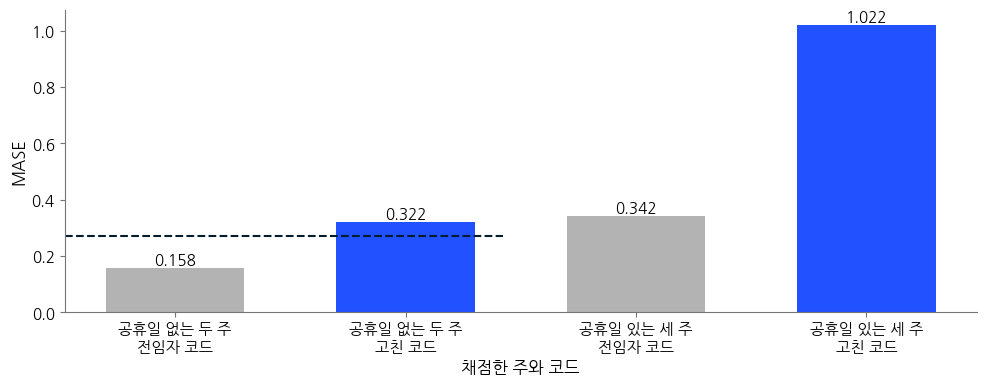

In [7]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다. 아래는 전임 담당자가 남긴 코드라 오류 없이 돌아가지만 운영에 쓸 수 없는 코드입니다.
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 튜터가 AI 코드 표시선 아래를 다시 씁니다.
# 고칠 지시는 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 대화창에만 쓰면 진단은 나오지만 완성본 풀이가 열리지 않습니다
PROMPT = """
전임 담당자 코드는 panel_frame(origin) 한 표를 원점 앞뒤로 잘라 df 와 future_df 를 만드는데, future_df 에 하차 인원 alight 가 남아 있다. 채점 7일의 하차 인원은 예측하는 원점 아침에는 알 수 없는 값(과거 공변량)이라, future_df 에 넣으면 데이터 누수가 된다. 이걸 고쳐 줘.

미션 2 준비 셀이 만든 이름(ORIGINS, PLAIN_ORIGINS, HOL_ORIGINS, QS, H, PIPE, panel_frame, mase_of, COL, FIG_W)은 다시 만들거나 덮어쓰지 마.

1. 두 코드로 각각 예측해서 나란히 모아.
   - 전임자 코드: 원래 예측 부분은 그대로 두고, 원점마다 그 결과 표로 mase_of(origin, fc) 를 구해 저장해.
   - 고친 코드: 같은 원점마다 p = panel_frame(origin) 에서
     df = timestamp 가 원점보다 이른 행, 열은 item_id·timestamp·target·holiday (alight 제외)
     future_df = timestamp 가 원점 이후(원점 포함) 7일 행, 열은 item_id·timestamp·holiday 만 (target 과 alight 제외)
     로 만들어. 평가표의 Chronos-2 + 공휴일과 같은 조건이 되도록 두 표 모두에서 alight 를 뺀다.
     PIPE.predict_df(df, future_df=future_df, prediction_length=H, quantile_levels=QS) 로 예측하고 mase_of(origin, fc) 로 MASE 를 저장해.
   - 원점별 값을 먼저 다 구한 뒤, 두 코드 각각 HOL_ORIGINS 세 원점과 PLAIN_ORIGINS 두 원점을 따로 평균해.

2. 출력: 아래 두 줄을 이 이름 그대로 출력해. 「=」 뒤에는 값 하나만 적어.
   - future_df 공변량 열 수 = (고친 future_df 에서 item_id·timestamp 를 뺀 열의 수, 정수)
   - 공휴일 있는 세 주 MASE 차(고친 코드 − 전임자 코드) = (고친 코드의 공휴일 있는 세 주 평균 MASE − 전임자 코드의 같은 값, 소수 셋째 자리)
   그 밑에 참고로 공휴일 유무별 두 코드의 평균 MASE 를 소수 셋째 자리로 출력하고, 고친 코드의 공휴일 없는 두 주 값을 제로샷 0.271 과 나란히 적어. 고친 future_df 의 열 목록도 한 줄 출력해.

3. 지울 것: 「판단 :」 으로 시작하는 행은 전임자 코드에 있던 것도 지우고, 새로도 쓰지 마.

4. 그래프 한 장: 막대 4개(공휴일 없는 두 주·전임자 코드, 공휴일 없는 두 주·고친 코드, 공휴일 있는 세 주·전임자 코드, 공휴일 있는 세 주·고친 코드). 고친 코드 막대만 다른 색으로 칠하고, 공휴일 없는 두 주 쪽에 제로샷 0.271 가로 점선을 그어. 가로축 이름은 「채점한 주와 코드」, 세로축 이름은 「MASE」로 달고, 막대 위에 값을 적어. 색은 COL, 가로 크기는 FIG_W 를 써.

"""
# --- 여기부터 AI 코드 ---
res_legacy = {}
res_fixed = {}

for o in ORIGINS:
    panel = panel_frame(o)

    df_legacy = panel[panel["timestamp"] < pd.Timestamp(o)]
    future_df_legacy = panel[panel["timestamp"] >= pd.Timestamp(o)].drop(columns=["target"])
    fc_legacy = PIPE.predict_df(df_legacy, future_df=future_df_legacy, prediction_length=H, quantile_levels=QS)
    res_legacy[o] = mase_of(o, fc_legacy)

    df_fixed = panel.loc[panel["timestamp"] < pd.Timestamp(o), ["item_id", "timestamp", "target", "holiday"]]
    future_df_fixed = panel.loc[panel["timestamp"] >= pd.Timestamp(o), ["item_id", "timestamp", "holiday"]]
    fc_fixed = PIPE.predict_df(df_fixed, future_df=future_df_fixed, prediction_length=H, quantile_levels=QS)
    res_fixed[o] = mase_of(o, fc_fixed)

plain_legacy = np.mean([res_legacy[o] for o in PLAIN_ORIGINS])
hol_legacy = np.mean([res_legacy[o] for o in HOL_ORIGINS])
plain_fixed = np.mean([res_fixed[o] for o in PLAIN_ORIGINS])
hol_fixed = np.mean([res_fixed[o] for o in HOL_ORIGINS])

n_cov = len(future_df_fixed.columns) - 2
hol_diff = hol_fixed - hol_legacy

print(f"future_df 공변량 열 수 = {n_cov}")
print(f"공휴일 있는 세 주 MASE 차(고친 코드 − 전임자 코드) = {hol_diff:.3f}")
print()
print(f"공휴일 없는 두 주 MASE — 전임자 코드 = {plain_legacy:.3f} · 고친 코드 = {plain_fixed:.3f}")
print(f"공휴일 있는 세 주 MASE — 전임자 코드 = {hol_legacy:.3f} · 고친 코드 = {hol_fixed:.3f}")
print(f"고친 코드 공휴일 없는 두 주 MASE {plain_fixed:.3f} vs 제로샷 0.271")
print(f"고친 future_df 열 목록 = {list(future_df_fixed.columns)}")

fig, ax = plt.subplots(figsize=(FIG_W, 4))
labels = ["공휴일 없는 두 주\n전임자 코드", "공휴일 없는 두 주\n고친 코드",
          "공휴일 있는 세 주\n전임자 코드", "공휴일 있는 세 주\n고친 코드"]
values = [plain_legacy, plain_fixed, hol_legacy, hol_fixed]
colors = [COL["연회색"], COL["파랑"], COL["연회색"], COL["파랑"]]

bars = ax.bar(labels, values, color=colors, width=0.6)
ax.bar_label(bars, fmt="%.3f")
ax.axhline(0.271, xmin=0.0, xmax=0.48, color=COL["남색"], linestyle="--")
ax.set_xlabel("채점한 주와 코드")
ax.set_ylabel("MASE")
plt.tight_layout()
plt.show()

## 오늘의 결론

<div class="lms-summary">

**정리**

- 공휴일 있는 세 주: 평균 MASE 가 표 3 의 제로샷 2.763 에서 미션 1 의 Chronos-2 + 공휴일 1.022 로 내려왔습니다. 차이 1.741 은 시드 범위 0.077 보다 큽니다. 강남역의 설 연휴 평일 이틀은 Chronos-2 + 공휴일도 실제보다 높게 예측했습니다(그림 1). 그래서 설 연휴가 있는 주도 Chronos-2 + 공휴일의 예측을 쓰고, 설 연휴 평일 이틀만 계절 나이브 예측 × 지난해 같은 날의 비로 바꿉니다
- 공휴일 없는 두 주: 제로샷 0.271 에서 Chronos-2 + 공휴일 0.322 로 0.051 높아졌습니다. 이 차이는 0.077 보다 작아 평균 MASE 만으로는 어느 모델이 더 낫다고 하지 않습니다. 역 100개와 원점 2개의 조합 200건 가운데 148건은 MASE 가 높아졌습니다. 두 모델 모두 MASE 가 계절 나이브 0.445 보다 0.077 넘게 낮습니다
- `future_df` 에 하차가 남은 전임 담당자 코드는 공휴일 없는 두 주 0.158 · 공휴일 있는 세 주 0.342 로 좋아 보였지만, 예측 시점에는 알 수 없는 값을 입력한 누수였습니다. 두 표에서 하차를 모두 빼면 0.322 · 1.022 이고(공휴일 있는 세 주의 차이 1.022 − 0.342 = 0.680), 「모든 주에 쓰자」의 근거였던 0.158 이 사라집니다(미션 2)
- 할 일: `chronos_frames(o, holiday=True)` 처럼 `future_df` 에는 `holiday` 만 포함합니다. `alight` 같은 과거 공변량은 쓰더라도 `df` 에만 포함합니다. 평가표에는 「Chronos-2 + 공휴일」의 MASE 를 공휴일 없는 두 주와 공휴일 있는 세 주로 나눠 나란히 적습니다

평일 공휴일이 있는 주에는 Chronos-2 + 공휴일을 역별 인력 예측에 씁니다. 공휴일 없는 주에 무엇을 쓸지는 이론 팀 라운드에서 정한 입장을 따릅니다.

</div>

> **[과제] 실습 제출 — 주를 나눠 채점하고 누수 고치기**
>
> 미션 1·2 의 「PROMPT 셀」이 채점을 통과한 상태로 노트북을 제출합니다. PROMPT 는 내가 쓴 그대로 둡니다.
>
> 마감: 2026-10-21T23:59+09:00
>
> **평가 기준**
>
> | 기준 | 이렇게 하면 충족 | 배점 |
> | --- | --- | --- |
> | 미션 1 | 채점을 통과했고 PROMPT 에 만들 것이 내 말로 적혀 있다 | 50 |
> | 미션 2 | 채점을 통과했고 PROMPT 에 고칠 것이 내 말로 적혀 있다 | 50 |
>
> 제출은 LMS 레슨 화면의 과제 카드에서 GitHub 링크로 합니다(이 파일에 적으면 제출되지 않습니다).

<div style="background:#F2F2F2;color:#000000;padding:28px;border-radius:12px;border:1px solid #E6E6E6;margin-top:16px;border-left:4px solid #051C2C">
<h2 style="color:#000000;margin:0 0 8px 0">수고했습니다 — 딥러닝 시계열 셋째 날 완료</h2>
<div style="color:#656565">공휴일 열을 미래 입력에 포함한 Chronos-2 를 공휴일이 있는 주와 없는 주로 나눠서 다시 채점하고, 미래 입력에 남은 하차 열을 찾아 고쳤습니다.</div>
</div>